<a href="https://colab.research.google.com/github/Marlon-Sbardelatti/machine-learning/blob/feature%2Ftrabalho-04/trabalho-04/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **Equipe**: 01<br>
> **Estudantes**: Cristina Siewert Jansen, Marlon Sbardelatti e Sofia Sousa Lindner

# **REDES NEURAIS ARTIFICIAIS**

# PARTE 2: Redes Neurais e CNN - Identificação de Objetos

Neste trabalho iremos fazer a identificação de um conjunto de dados de imagens de artigos de Zalando chamado Fashion-MNIST, que consiste em um conjunto de treinamento de 60.000 exemplos e um conjunto de teste de 10.000 exemplos. Cada exemplo é uma imagem em tons de cinza 28x28, associada a um rótulo de 10 classes.

Fonte: https://www.tensorflow.org/datasets/catalog/fashion_mnist?hl=pt-br

## **ATIVIDADE:**

**Descrição:**

Nesta atividade, você receberá um código de uma Rede Neural Artificial e uma Rede Neural Convolucional (CNN) implementada. Sua tarefa é analisar o código fornecido e fazer uma interpretação detalhada de cada linha, identificando e explicando as principais etapas, camadas e operações realizadas pela RNA e pela CNN.

**Instruções:**

1. Preencha o código com comentários em cada linha, explicando sua função e propósito.
2. Analise o código cuidadosamente para entender como a CNN é configurada.
3. Identifique e explique as camadas de convolução, camadas de pooling, camadas densas, funções de ativação, tamanhos dos filtros, número de neurônios, etc.
4. Identifique quais técnicas de regularização ou otimização formam utilizadas no código e explique como elas contribuem para o desempenho e a generalização do modelo.
5. Comente sobre a função de ativação utilizada na camada de saída.
6. Descreva os hiperparâmetros e ajustes do modelo, como a taxa de aprendizado, número de épocas de treinamento e o tratamento dos conjuntos de dados de treinamento e teste.
7. Faça uma avaliação descritiva dos resultados das Redes Neurais implementadas.



**Entregável:**

Prepare uma análise detalhada do código fornecido, destacando as principais características da CNN e como ela é configurada para a tarefa em questão. Se necessário, inclua observações sobre o potencial de melhoria ou otimização do modelo.

Esta atividade visa consolidar seu conhecimento sobre CNNs, ajudando a compreender como uma Rede Neural Convolucional é implementada e configurada para tarefas específicas.

In [ ]:
# Importa bibliotecas do Tensorflow sobre CNNs
import tensorflow as tf
from tensorflow import keras

In [ ]:
# Importa bibliotecas para manipulação do dataset
import numpy as np                    # Permite transformação dos dados através de tensores
import pandas as pd                   # Permite uso de Dataframes
from matplotlib import pyplot as plt  # Permite plotagem
%matplotlib inline

## Importando base de dados

In [ ]:
# Atribui dataset Fashion-MNIST à variável
fashion_mnist = keras.datasets.fashion_mnist


In [ ]:
# Realiza download do dataset, separando em X (features) e y (labels) de teste e treino
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [ ]:

print(X_train_full.shape) # Imprime dimensões do tensor de amostras de TREINO
print(y_train_full.shape) # Imprime total de rótulos de TREINO

print(X_test.shape)       # Imprime dimensões do tensor de amostras de TESTE
print(y_test.shape)       # Imprime total de rótulos de TESTE

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


A saída da célula confirma as informações fornecidas sobre o dataset: `X_train_full` e `X_test` são tensores tridimensionais cujo shape revela, respectivamente, número de amostras, altura e largura de cada imagem, em pixels. A ausência de uma quarta dimensão também confirma o fato de estarem em grayscale.<br>

Dessa forma, pode-se afirmar que o conjunto de treino é composto por 60.000 imagens 28x28, enquanto o conjunto de teste é composto por 10.000 imagens 28x28, o que configura um split de ≈ 15% para teste.

In [ ]:
# Divide eixo X do conjunto de treinamento em: validação e treino
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0 # Normaliza intensidade dos pixels
                                                                            # para intervalo [0,1]

# Divide eixo y do conjunto de treinamento em: validação e treino
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

O conjunto original de treinamento é dividido em dois subconjuntos: 5000 imagens são reservadas para validação do modelo, enquanto as 55000 restantes são utilizadas para treinamento, ou seja, ajustar os pesos da rede. Essa divisão configura um split de ≈ 9% para validação.<br>

Em seguida, os valores dos pixels, originalmente no intervalo [0, 255], são normalizados para [0, 1] por meio da divisão por 255 (branco), permitindo uma convergência mais estável do processo de aprendizado.

In [ ]:
# Cria lista de labels para facilitar a leitura das predições (número -> nome)
nomes_classes = ["camisa/top", "calca", "casaco", "vestido", "jaqueta",
               "sandalia", "camiseta", "tenis", "bolsa", "bota"]

In [ ]:
# Testa verificar a classe da amostra de índice 5 do conjunto de treino,
# convertendo o número do rótulo para o nome correspondente
nomes_classes[y_train[5]]

'bota'

In [ ]:
# Imprime valor da amostra de índice 5: pixels normalizados com valor entre [0,1]
X_train[5]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

bota


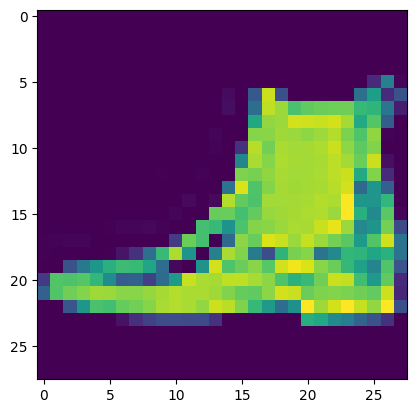

In [ ]:
exemplo_n = 5

# Imprime nome da classe da amostra 5
print(nomes_classes[y_train[exemplo_n]])

# Exibe a amostra 5 como imagem, com interpolação "nearest"
# para manter os pixels visivelmente separados
plt.imshow(X_train[exemplo_n], interpolation='nearest')
plt.show()

##  Rede Neural Artificial com Keras

In [ ]:
nn = keras.models.Sequential()

# Converte cada imagem 28x28 em um vetor unidimensional
nn.add(keras.layers.Flatten(input_shape=[28, 28]))

# 1ª camada oculta com 300 neurônios para extração inicial
nn.add(keras.layers.Dense(300, activation="relu"))

# Desliga aleatoriamente 10% dos neurônios durante o treinamento para reduzir overfitting
nn.add(keras.layers.Dropout(rate=0.1))

# 2ª camada oculta com 100 neruônios para aprender representações mais abstratas
nn.add(keras.layers.Dense(100, activation="relu"))

# Novo dropout de 10% para melhorar a capacidade de generalização
nn.add(keras.layers.Dropout(rate=0.1))

# Camada de saída com 10 neurônios, um para cada classe de objeto
nn.add(keras.layers.Dense(10, activation="softmax"))

nn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

A rede neural é composta por uma camada de entrada, duas camadas ocultas e uma camada de saída. Inicialmente, a camada Flatten transforma cada imagem de dimensão 28×28 pixels em um vetor unidimensional de 784 elementos, como demonstrado na saída da célula. Essa etapa é necessária porque as camadas densas operam sobre vetores e não sobre matrizes bidimensionais, que é o caso de imagens.

A primeira camada oculta possui 300 neurônios e utiliza a função de ativação ReLU, que foi escolhida por apresentar baixo custo computacional e minimizar o problema do desaparecimento do gradiente. O número de 300 neurônios provavelmente foi definido buscando extrair características relevantes sem aumentar excessivamente a complexidade do modelo.

Após essa camada, foi adicionada uma camada de Dropout com taxa de 10%, que desativa aleatoriamente parte dos neurônios durante o treinamento. Essa técnica reduz a dependência entre neurônios específicos e ajuda a evitar overfitting.

A segunda camada oculta contém 100 neurônios, também com função de ativação ReLU. A redução gradual do número de neurônios provavelmente foi adotada porque permite construir representações mais abstratas das características aprendidas na camada anterior, diminuindo também o número total de parâmetros do modelo.

A camada de saída é composta por 10 neurônios, que correspondem às dez classes possíveis para predição. A função de ativação Softmax converte as saídas em probabilidades, possibilitando que a classe prevista seja aquela de maior probabilidade.

### Compilando e treinando o modelo

In [ ]:
%time
# Compila o modelo
nn.compile(
  loss="sparse_categorical_crossentropy", # Função de perda adequada pra múltiplas classes
  optimizer="sgd",                        # Otimizador SGD pra ajuste de learning rate
  metrics=["accuracy"]                    # Define acurácia como métrica de validação
)

# Realiza o treinamento do modelo com os subconjuntos de treinamento e 5 épocas (passadas sobre o dataset)
history_nn = nn.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 33.9 µs
Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7358 - loss: 0.7861 - val_accuracy: 0.8256 - val_loss: 0.5220
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8152 - loss: 0.5353 - val_accuracy: 0.8426 - val_loss: 0.4575
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8330 - loss: 0.4789 - val_accuracy: 0.8536 - val_loss: 0.4203
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8436 - loss: 0.4436 - val_accuracy: 0.8670 - val_loss: 0.3927
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8515 - loss: 0.4202 - val_accuracy: 0.8634 - val_loss: 0.3810


No treinamento, foi utilizada a função de perda `sparse_categorical_crossentropy`, adequada para problemas de classificação com múltiplas classes (nesse caso, 10) e rótulos inteiros, juntamente com o otimizador SGD (Stochastic Gradient Descent) e a métrica de acurácia. O SGD atualiza os pesos do modelo usando apenas um exemplo escolhido de forma aleatória a cada iteração, o que faz com que o modelo evite soluções subótimas. Essa escolha estocástica, porém, pode acabar gerando certo ruído, produzindo uma convergência instável. Além disso, a escolha de 5 épocas parece ser insuficiente, sendo que o ideal é escolher um valor acima de 20 e, nesse caso, usar um EarlyStopping para economizar tempo de treinamento.

### Visualizar a performance

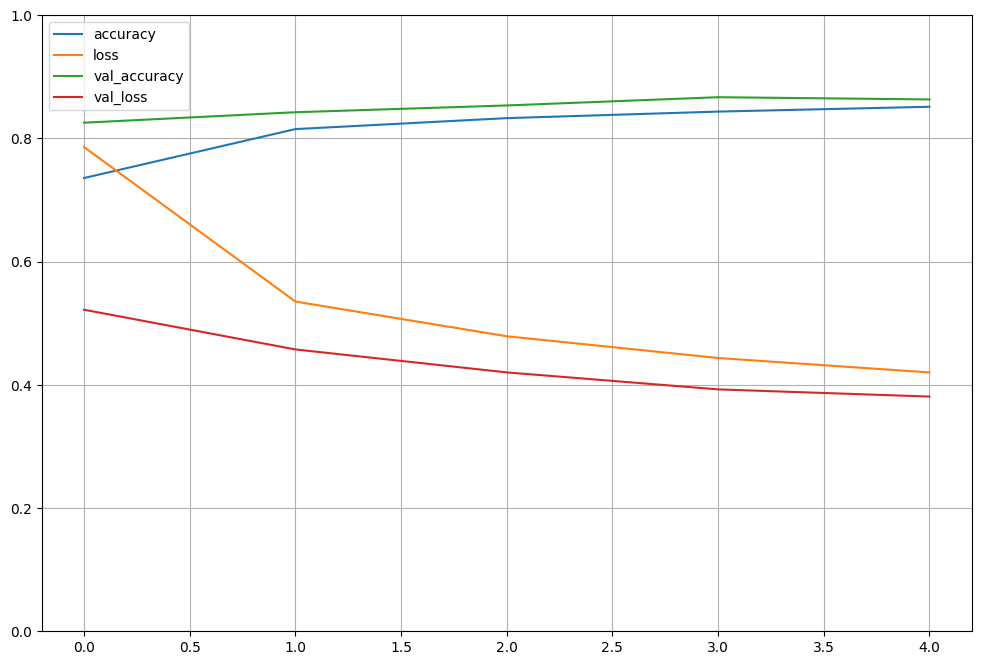

In [ ]:
# Transforma histórico do treinamento em dataframe
pd.DataFrame(history_nn.history).plot(figsize=(12, 8))

# Habilita grid na imagem
plt.grid(True)

# Altera escala do eixo y para intervalo [0,1]
plt.gca().set_ylim(0, 1)

# Exibe gráfico final de performance
plt.show()

As acurácias de treino e validação crescem conforme tempo de treinamento, sendo que, como esperado, a de validação é levemente mais estável. Com relação à perda, ambas baixaram conforme treinamento, mas a de treinamento demorou mais para alcançar certa estabilidade por conta do Dropout ativado, que, propositalmente, acaba gerando mais erro durante o treinamento para que o modelo se generalize.

### Avaliar o modelo

In [ ]:
# Imprime total de perda e acurácia para dados de TESTE
nn.evaluate(X_test, y_test,verbose=1) # Acurácia = 81,15%

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8115 - loss: 70.1111


[70.11112213134766, 0.8115000128746033]

###Realizar uma Previsão

In [ ]:
# Seleciona apenas as 4 primeiras imagens de TESTE
X_novo = X_test[:4]

# Realiza previsão das 4 imagens, produzindo uma matriz de probabilidades
y_proba = nn.predict(X_novo)

# Exibe matriz de probabilidades para cada uma das 10 classes
y_proba

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

Por ter sido usada a camada de saída Softmax com 10 neurônios, para cada amostra de entrada, é produzida uma lista de probabilidades, uma para cada classe de objeto. Dessa forma, o resultado da célula é uma matriz 4x10, sendo que, para cada linha (amostra), a rede demonstrou 100% de probabilidade para a classe prevista.

In [ ]:
# Faz novamente a previsão, dessa vez selecionando a classe com maior probabilidade
y_pred = np.argmax(nn.predict(X_novo), axis=-1)

# Imprime número das classes prevista
print(y_pred)

# Imprime nome de cada classe prevista
print(np.array(nomes_classes)[y_pred])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
[9 2 1 1]
['bota' 'casaco' 'calca' 'calca']


### Verificar os resultados

In [ ]:
# Recupera rótulos reais das 4 primeiras imagens do conjunto de TESTE
y_novo = y_test[:4]

# Imprime número dos rótulos
print(y_novo)

# Imprime nome das classes
np.array(nomes_classes)[y_pred]

[9 2 1 1]


array(['bota', 'casaco', 'calca', 'calca'], dtype='<U10')

calca


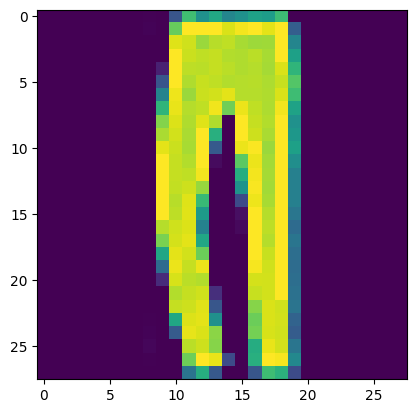

In [ ]:
# Imprime nome da classe prevista para 2ª amostra
print(nomes_classes[y_pred[2]])

# Exibe imagem de entrada da 2ª amostra
plt.imshow(X_novo[2], interpolation='nearest')
plt.show()

## Treinando CNN com Keras

In [ ]:
cnn = keras.models.Sequential([

    # Entrada das imagens em escala de cinza: 28x28 pixels e 1 canal (grayscale)
    keras.layers.InputLayer(input_shape=(28,28,1)),

    # Camada de convolução com 64 filtros 5x5 pra características básicas
    keras.layers.Conv2D(
        64, 5,
        activation='relu',
        padding='same',
        kernel_initializer='glorot_uniform'),

    # Camada de Max Pooling com janela 2x2 pra reduzir mapa de características
    keras.layers.MaxPool2D(2),

    # Camada de convolução com 128 filtros 3x3 pra características mais complexas
    keras.layers.Conv2D(128, 3, activation='relu', padding='same'),

    # Camada igual pra refinamento das características extraídas
    keras.layers.Conv2D(128, 3, activation='relu', padding='same'),

    # Nova camada pra redução da dimensão espacial
    keras.layers.MaxPool2D(2),

    # Extração de características de alto nível
    keras.layers.Conv2D(258, 3, activation='relu', padding='same'),

    # Refinamento das características profundas
    keras.layers.Conv2D(258, 3, activation='relu', padding='same'),

    # Última redução espacial
    keras.layers.MaxPool2D(2),

    # Converte os mapas de características em vetor unidimensional
    keras.layers.Flatten(),

    # Combina as características extraídas para classificação
    keras.layers.Dense(128, activation="relu"),

    # Regularização de 50% contra overfitting
    keras.layers.Dropout(rate=0.5),

    keras.layers.Dense(64, activation="relu"),

    # Última regularização de 50%
    keras.layers.Dropout(rate=0.5),

    # 10 neurônios para as 10 classes de objeto
    keras.layers.Dense(10, activation="softmax")
])

Neste segundo modelo, diferentemente do primeiro, a arquitetura é de uma CNN formada por três blocos convolucionais seguidos por duas camadas densas. A camada de entrada recebe imagens em escala de cinza de dimensão 28×28 pixels.

A primeira camada convolucional possui 64 filtros de tamanho 5×5 e função de ativação ReLU. O kernel de 5x5 poderia ser 3x3, porque kernels menores extraem mais detalhes locais. Seu objetivo é detectar características básicas da imagem, como bordas, contornos e texturas. O preenchimento `same` foi utilizado para preservar as dimensões espaciais da imagem durante a convolução.

Após essa etapa, a camada de Max Pooling com janela 2×2 permite reduzir a resolução espacial dos mapas de características pela metade, diminuindo a quantidade de parâmetros.

O segundo bloco convolucional é composto por duas camadas com 128 filtros 3×3, responsáveis por aprender características mais complexas a partir das extrações realizadas anteriormente. Em seguida, um novo Max Pooling reduz novamente as dimensões espaciais, priorizando características mais relevantes.

O terceiro bloco repete essa estratégia utilizando duas camadas convolucionais com 258 filtros 3×3, permitindo que a rede capture padrões de maior nível semântico. O parâmetro 258 poderia ser definido como 256, porque seria exatamente o dobro dos filtros utilizados nos blocos de convolução anteriores, mantendo uma progressão natural. Após a última operação de Max Pooling, os mapas de características são convertidos em um vetor unidimensional pela camada Flatten.

As camadas densas de 128 e 64 neurônios, ambas com função ReLU, realizam a combinação das características extraídas pelas camadas convolucionais. Entre elas foram inseridas camadas Dropout com taxa de 50% a fim de reduzir o overfitting, tornando o modelo mais adaptável a dados genéricos. No entanto, o valor de 50% pode ser um pouco agressivo, visto que metade dos neurônios seriam desligados. Nesse caso, talvez 20% ou 30% seriam valores mais adequados.

Por fim, a camada de saída possui 10 neurônios e função Softmax, como no modelo anterior, produzindo uma distribuição de probabilidades correspondente às dez classes de objetos do Fashion-MNIST.

In [ ]:
# Exibe camadas da CNN, cada qual com shape e número de parâmetros
cnn.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 7, 7, 258)      │       297,474 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 7, 7, 258)      │       599,334 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 3, 3, 258)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2322)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       297,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,426,162 (5.44 MB)

 Trainable params: 1,426,162 (5.44 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Imprime dimensões originais do tensor de treinamento
print(X_train.shape) # 3 dimensões: amostras, largura, altura

# Redimensiona tensor de TREINO para 4 dimensões
X_train_new = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2],1)

# Redimensiona tensor de VALIDAÇÃO para 4 dimensões
X_valid_new = X_valid.reshape(X_valid.shape[0], X_valid.shape[1], X_valid.shape[2],1)

# Redimensiona tensor de TESTE para 4 dimensões
X_test_new = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2],1)

# Imprime dimensões do tensor de treino ajustado
print(X_train_new.shape)

(55000, 28, 28)
(55000, 28, 28, 1)


O reajuste foi necessário porque as camadas de convolução esperam uma entrada de 4 dimensões: número de amostras, largura, altura e canais. Como as imagens estão em escala cinza (grayscale), todas recebem 1 canal na última dimensão.

In [ ]:
# Compila o modelo, mantendo parâmetros do anterior
cnn.compile(
  loss="sparse_categorical_crossentropy",   # Perda adequada para múltiplas classes
  optimizer="sgd",                          # Otimizador SGD
  metrics=["accuracy"]                      # Métrica de acurácia pra validação
)

# Treina o modelo com os tensores ajustados de TREINO e VALIDAÇÃO e 20 épocas
history_cnn = cnn.fit(X_train_new, y_train, epochs=20, validation_data=(X_valid_new, y_valid))

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 712s 413ms/step - accuracy: 0.4906 - loss: 1.3635 - val_accuracy: 0.7598 - val_loss: 0.7174
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 716s 417ms/step - accuracy: 0.7062 - loss: 0.7983 - val_accuracy: 0.7984 - val_loss: 0.5547
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 738s 415ms/step - accuracy: 0.7631 - loss: 0.6608 - val_accuracy: 0.8226 - val_loss: 0.4731
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 718s 418ms/step - accuracy: 0.7935 - loss: 0.5809 - val_accuracy: 0.8478 - val_loss: 0.4163
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 721s 420ms/step - accuracy: 0.8119 - loss: 0.5306 - val_accuracy: 0.8522 - val_loss: 0.3959
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 740s 419ms/step - accuracy: 0.8269 - loss: 0.4949 - val_accuracy: 0.8658 - val_loss: 0.3767
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 734s 414ms/step - accuracy: 0.8371 - loss: 0.4656 - val_accuracy: 0.8732 - val_loss: 0.3604
Epoch 8/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 749s 418ms/step - ac

Os parâmetros do modelo anterior foram mantidos na compilação da CNN, ainda que, como sugerido antes, o otimizador SGD pudesse ser trocado pelo Adam para uma convergência mais estável. Por outro lado, o treinamento desta vez utilizou 20 épocas, o que já é mais adequado para o problema em relação às 5 da anterior. No entanto, para 20 épocas o mais o ideal seria utilizar um EarlyStopping, visando economizar custo computacional e tempo de treinamento quando não houver melhora.

### Avaliar o modelo

In [ ]:
cnn.evaluate(X_test_new, y_test,verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.8735 - loss: 28.0920


[28.091962814331055, 0.8734999895095825]

Os resultados evidenciam um desempenho superior da rede neural convolucional em comparação com a MLP. Enquanto a MLP atingiu aproximadamente 81% de acurácia, a CNN alcançou 87,35%, indicando maior capacidade de generalização e classificação das imagens do conjunto Fashion-MNIST. Além disso, observou-se uma redução significativa da função de perda, sugerindo que as previsões realizadas pela CNN apresentaram menor erro médio durante o processo de classificação. Esse ganho pode ser atribuído à capacidade das camadas convolucionais de explorar as relações espaciais entre os pixels e extrair automaticamente características relevantes das imagens, algo que não ocorre na MLP, que recebe apenas um vetor unidimensional após a etapa de achatamento (flattening).

Em contrapartida, o aumento da complexidade arquitetural implicou em um maior custo computacional. O treinamento da CNN demandou aproximadamente quatro horas com CPU, tempo substancialmente superior ao da MLP, por conta da maior quantidade de parâmetros e operações convolucionais realizadas. Além disso, o treinamento foi executado sem a utilização de técnicas como EarlyStopping, o que pode ter contribuído para a execução de épocas adicionais sem ganhos significativos de desempenho.

Embora a CNN tenha apresentado desempenho superior à MLP, os resultados obtidos ainda podem ser aprimorados por meio do ajuste de hiperparâmetros e da adoção de técnicas adicionais de regularização e otimização, como EarlyStopping, BatchNormalization e o otimizador Adam. Essas estratégias tendem a acelerar a convergência e elevar a acurácia do modelo, mantendo um custo computacional mais equilibrado.

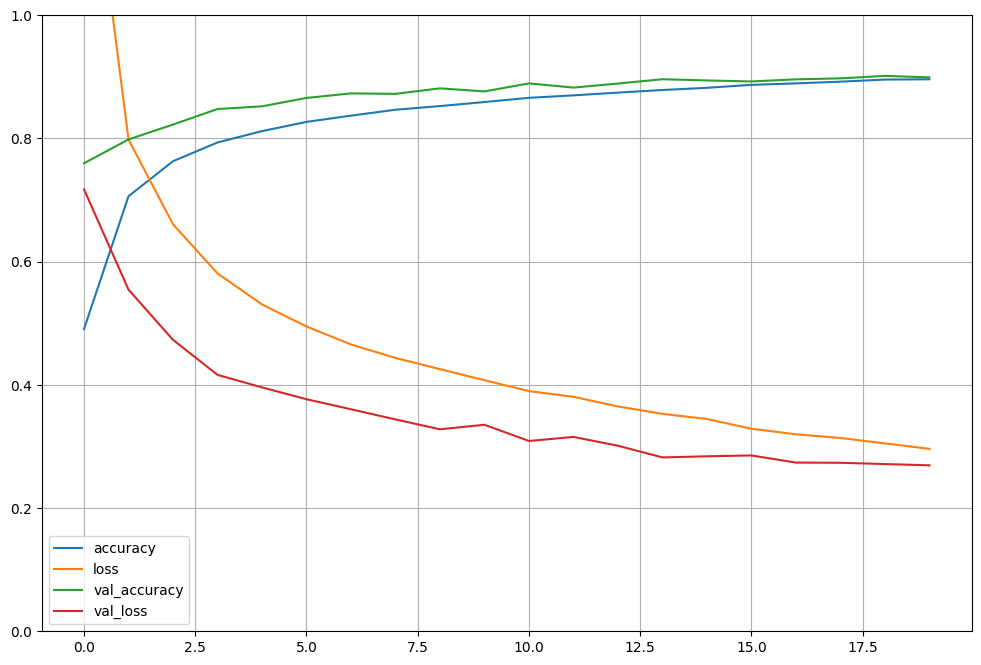

In [ ]:
# Cria um dataframe do histórico de desempenho da CNN
pd.DataFrame(history_cnn.history).plot(figsize=(12, 8))

# Habilita grades no gráfico
plt.grid(True)

# Ajusta intervalo do eixo y para [0,1]
plt.gca().set_ylim(0, 1)

# Exibe gráfico
plt.show()

O gráfico apresenta a evolução das métricas de treinamento e validação da rede neural convolucional ao longo das épocas de treinamento. Verifica-se um aumento gradual da acurácia tanto no conjunto de treinamento quanto no de validação, atingindo aproximadamente 90% ao final do processo. Simultaneamente, as curvas de perda apresentam comportamento decrescente, evidenciando a convergência do algoritmo de aprendizado.

A proximidade entre as curvas de treinamento e validação indica boa capacidade de generalização do modelo e ausência de sinais expressivos de overfitting. Além disso, observa-se que as maiores melhorias ocorreram nas primeiras épocas, enquanto nas épocas finais os ganhos foram bem menos significativos. Esse comportamento sugere que a utilização de mecanismos como EarlyStopping poderia ter reduzido o tempo de treinamento sem comprometer o desempenho final.